# 02 — Custom CNN experiments (Owner A)

Owned by **Member A**. Run `models/custom_cnn/train.py` configs here and:

- Load `results/custom_cnn/<run>/metrics.csv` and plot loss/acc/auc curves
- Ablate: depth, base channels, augmentation on/off
- Report val/test ACC, F1, AUC
- Sanity-check the split produced by `src.data_pipeline.balanced_split`

Do not edit this notebook from branches owned by B or C. Clear outputs before commit.

In [2]:
from pathlib import Path
import json

# Project root
PROJECT_ROOT = Path.cwd().parent

RESULTS_DIR = PROJECT_ROOT / "results" / "custom_cnn"
RESULTS_JSON = RESULTS_DIR / "results.json"
CHECKPOINT = RESULTS_DIR / "best_model.pt"

print("Results directory:", RESULTS_DIR)
print("results.json exists:", RESULTS_JSON.exists())
print("best_model.pt exists:", CHECKPOINT.exists())

# Load final Custom CNN results
with open(RESULTS_JSON, "r", encoding="utf-8") as f:
    results = json.load(f)

print("\nTop-level keys:")
print(list(results.keys()))

print("\nModel:", results.get("model_name"))
print("Training time (seconds):", results.get("total_train_time_seconds"))

print("\nTest metric keys:")
print(list(results["test_metrics"].keys()))

print("\nCross-generator metric keys:")
print(list(results["cross_gen_metrics"].keys()))


Results directory: d:\Deep Fake\deepfake-detection\results\custom_cnn
results.json exists: True
best_model.pt exists: True

Top-level keys:
['model_name', 'history', 'total_train_time_seconds', 'test_metrics', 'cross_gen_metrics', 'generalization_gap_accuracy']

Model: custom_cnn
Training time (seconds): 9605.996394395828

Test metric keys:
['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'confusion_matrix', 'ms_per_image', 'y_true', 'y_prob']

Cross-generator metric keys:
['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'confusion_matrix', 'ms_per_image', 'y_true', 'y_prob']


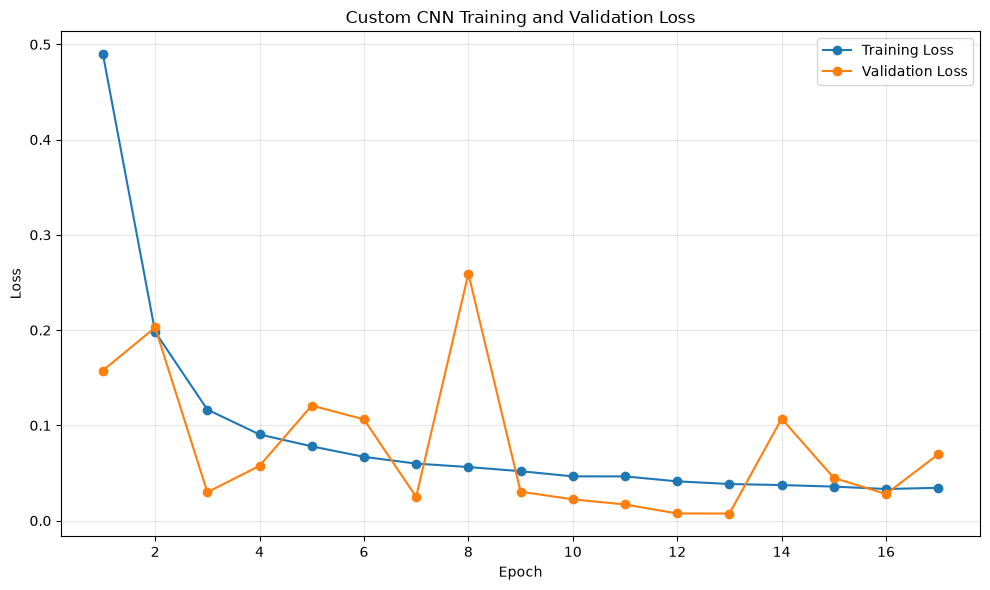

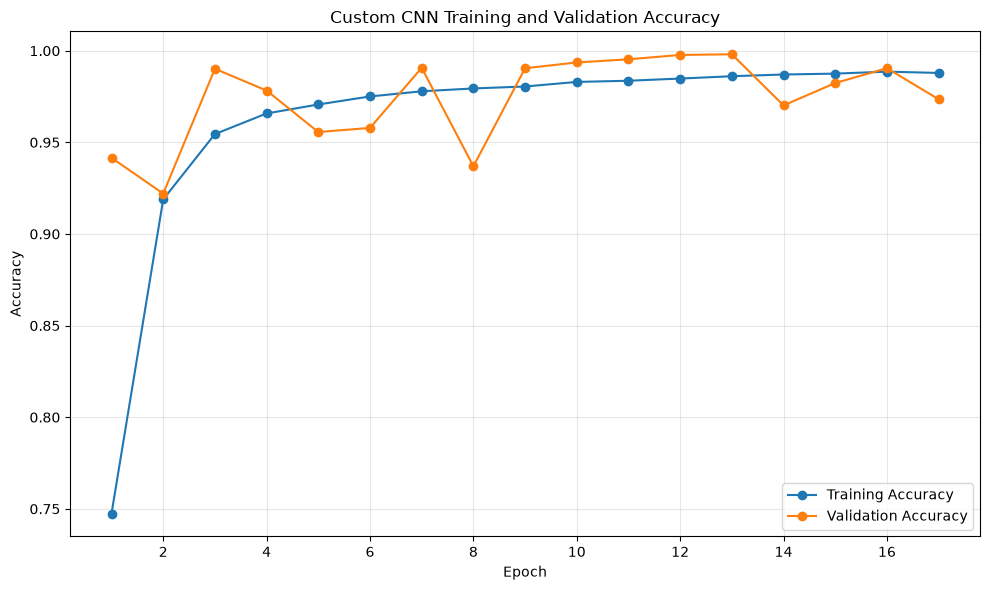

In [3]:
import matplotlib.pyplot as plt

history = results["history"]

epochs = range(1, len(history["train_loss"]) + 1)

# Training vs Validation Loss
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Training vs Validation Accuracy
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_acc"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Final Custom CNN evaluation metrics

import pandas as pd

# Get final results
test_metrics = results["test_metrics"]
cross_metrics = results["cross_gen_metrics"]

# Create comparison table
metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Inference Time (ms/image)"
    ],
    "Primary Test": [
        test_metrics["accuracy"],
        test_metrics["precision"],
        test_metrics["recall"],
        test_metrics["f1_score"],
        test_metrics["roc_auc"],
        test_metrics["ms_per_image"]
    ],
    "Cross-Generator Test": [
        cross_metrics["accuracy"],
        cross_metrics["precision"],
        cross_metrics["recall"],
        cross_metrics["f1_score"],
        cross_metrics["roc_auc"],
        cross_metrics["ms_per_image"]
    ]
})

# Display raw values
display(metrics_table)

,Metric,Primary Test,Cross-Generator Test
0,Accuracy,0.997881,0.888018
1,Precision,0.995449,0.238095
2,Recall,1.000000,0.010033
3,F1 Score,0.997719,0.019255
4,ROC-AUC,0.999984,0.637971
5,Inference Time (ms/image),1.592247,1.606246


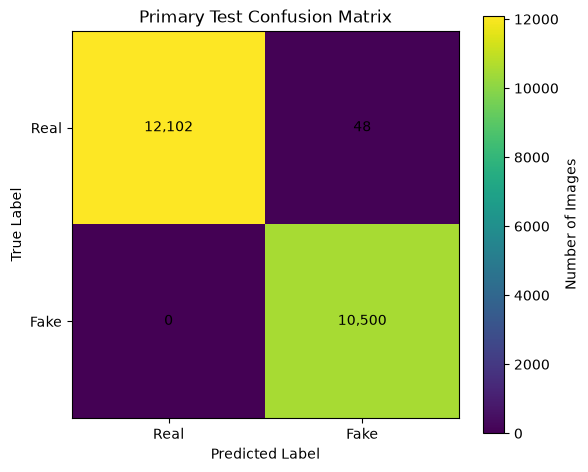

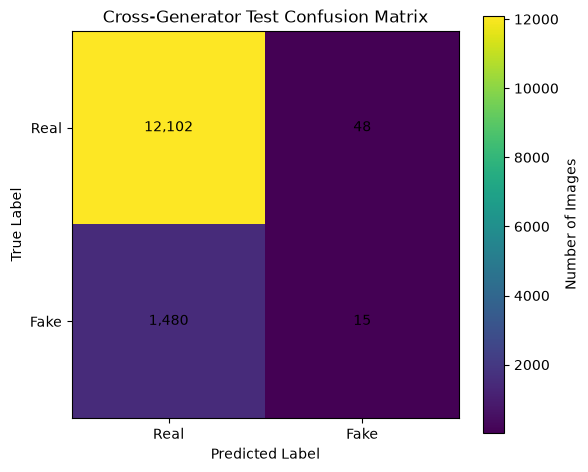

In [6]:
# Confusion matrices for Primary Test and Cross-Generator Test

import numpy as np
import matplotlib.pyplot as plt

primary_cm = np.array(test_metrics["confusion_matrix"])
cross_cm = np.array(cross_metrics["confusion_matrix"])

figures = [
    ("Primary Test Confusion Matrix", primary_cm),
    ("Cross-Generator Test Confusion Matrix", cross_cm)
]

for title, cm in figures:
    plt.figure(figsize=(6, 5))

    plt.imshow(cm, interpolation="nearest")

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.xticks([0, 1], ["Real", "Fake"])
    plt.yticks([0, 1], ["Real", "Fake"])

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                f"{cm[i, j]:,}",
                ha="center",
                va="center"
            )

    plt.colorbar(label="Number of Images")
    plt.tight_layout()
    plt.show()

Primary y_prob shape: (22650,)
Cross-generator y_prob shape: (13645,)
Primary Test ROC-AUC: 0.999984
Cross-Generator ROC-AUC: 0.637971


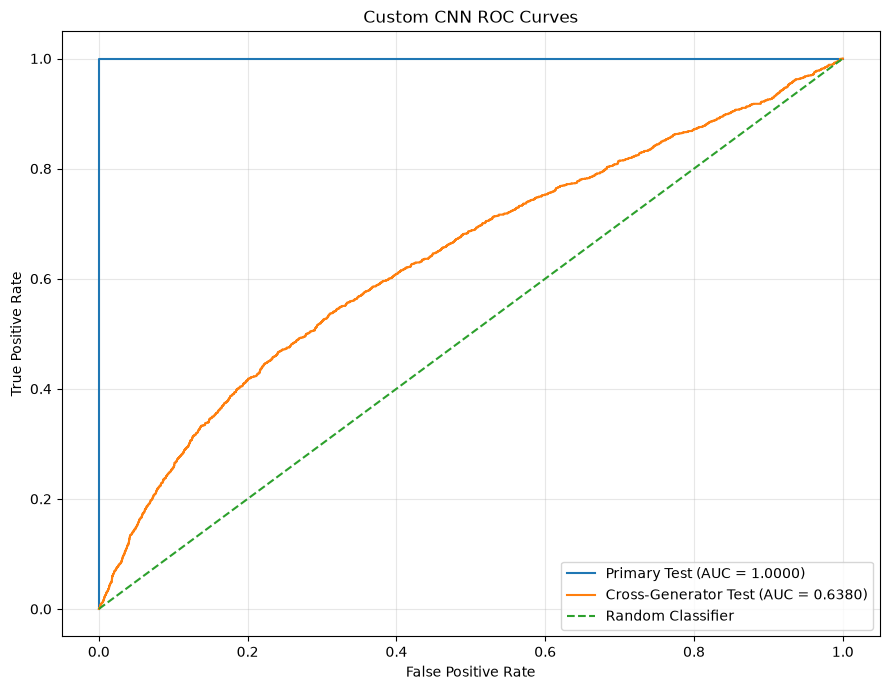

In [7]:
# ROC curves for Primary Test and Cross-Generator Test

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Convert saved values to NumPy arrays
primary_y_true = np.array(test_metrics["y_true"])
primary_y_prob = np.array(test_metrics["y_prob"])

cross_y_true = np.array(cross_metrics["y_true"])
cross_y_prob = np.array(cross_metrics["y_prob"])

# Check the probability format
print("Primary y_prob shape:", primary_y_prob.shape)
print("Cross-generator y_prob shape:", cross_y_prob.shape)

# If probabilities contain two class columns, use the Fake probability (class 1)
if primary_y_prob.ndim == 2:
    primary_scores = primary_y_prob[:, 1]
else:
    primary_scores = primary_y_prob

if cross_y_prob.ndim == 2:
    cross_scores = cross_y_prob[:, 1]
else:
    cross_scores = cross_y_prob

# Calculate ROC curves
primary_fpr, primary_tpr, _ = roc_curve(
    primary_y_true,
    primary_scores
)

cross_fpr, cross_tpr, _ = roc_curve(
    cross_y_true,
    cross_scores
)

# Calculate AUC from the saved probabilities
primary_auc = auc(primary_fpr, primary_tpr)
cross_auc = auc(cross_fpr, cross_tpr)

print(f"Primary Test ROC-AUC: {primary_auc:.6f}")
print(f"Cross-Generator ROC-AUC: {cross_auc:.6f}")

# Plot both ROC curves
plt.figure(figsize=(9, 7))

plt.plot(
    primary_fpr,
    primary_tpr,
    label=f"Primary Test (AUC = {primary_auc:.4f})"
)

plt.plot(
    cross_fpr,
    cross_tpr,
    label=f"Cross-Generator Test (AUC = {cross_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Custom CNN ROC Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Custom CNN generalization and computational summary

import sys
from pathlib import Path
import pandas as pd

# Find project root
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python import path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

# Generalization
primary_accuracy = test_metrics["accuracy"]
cross_accuracy = cross_metrics["accuracy"]
accuracy_gap = results["generalization_gap_accuracy"]

# Computational information
training_time_seconds = results["total_train_time_seconds"]
training_time_minutes = training_time_seconds / 60
training_time_hours = training_time_minutes / 60

# Import Custom CNN
from models.custom_cnn.model import CustomCNN

# Create the same architecture used for the final experiment
model = CustomCNN(
    in_channels=3,
    num_classes=2,
    base_channels=32,
    num_blocks=4,
    dropout=0.30
)

# Count trainable parameters
parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

# Create summary table
summary_table = pd.DataFrame({
    "Measure": [
        "Primary Test Accuracy",
        "Cross-Generator Accuracy",
        "Accuracy Generalization Gap",
        "Training Time (minutes)",
        "Training Time (hours)",
        "Trainable Parameters",
        "Primary Inference Time (ms/image)",
        "Cross-Generator Inference Time (ms/image)"
    ],
    "Value": [
        primary_accuracy,
        cross_accuracy,
        accuracy_gap,
        training_time_minutes,
        training_time_hours,
        parameter_count,
        test_metrics["ms_per_image"],
        cross_metrics["ms_per_image"]
    ]
})

display(summary_table)

Project root: d:\Deep Fake\deepfake-detection


,Measure,Value
0,Primary Test Accuracy,9.978808e-01
1,Cross-Generator Accuracy,8.880176e-01
2,Accuracy Generalization Gap,1.098632e-01
3,Training Time (minutes),1.600999e+02
4,Training Time (hours),2.668332e+00
5,Trainable Parameters,1.173730e+06
6,Primary Inference Time (ms/image),1.592247e+00
7,Cross-Generator Inference Time (ms/image),1.606246e+00
